This code plots the energy levels of a system defined by the spin hamiltonian, consisting of some combination of the terms below:
$$H = \underbrace{\mu_{B}\times B\times g\times S}_{\textrm{Electronic Zeeman}}+\underbrace{I\times A\times S}_{hyperfine}-\underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As a note notation I refer to the hyperfine and quadrapole as the static hamiltonian with respect to the magnetic field, and the zeeman terms as the dynamic hamiltonian with respect to the magnetic field.

In [48]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr

In [49]:
#spin Operators of Er:Y_2SiO_5:
Espin = 1/2
Ispin = 0

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)
excited = spin.cSpinHamiltonian(Espin,Ispin)


Paramaters taken from [Tian's Paper](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.104.054111)

In [50]:
#Z1 Ground Parameters
g_G = np.matrix([[7.085,0,-0],[0,7.085,0],[0,0,3.544]])

#Y1 Excited Parameters
g_E = np.matrix([[4.57,0,-0],[0,4.57,0],[0,0,4.51]])


#Pass our g tensors to the class so they can be used later
ground.setgE(g_G)
excited.setgE(g_E)


Sets up operators for optical transition strengths, given by
$$f_{ij}\propto \left|\left<i\right|\hat{O}\left|j\right>\right|^{2}$$
The $\hat{O}$ operators are related to the crystal symmetry and are generated from character tables such as on page 32 of [2010_Powell_Symmetry, Group Theory, and the Physical Properties of Crystals](https://www.dropbox.com/home/QIL_Resources/BookSections?preview=2010_Powell_Symmetry%2C+Group+Theory%2C+and+the+Physical+Properties+of+Crystals.pdf).[^1]

For spin transitions we can use some subset of the dynamic hamiltonian.

[^1]: Link may not work but should be in the dropbox

In [51]:
odim = ground.dim//2
print(odim)
#OS_pi = np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])
OS_pi = np.eye(2*odim)
OS_sigma = np.ones([odim*2,odim*2])

print(OS_pi)
print(OS_sigma)

OS_comb = OS_pi+OS_sigma

1
[[1. 0.]
 [0. 1.]]
[[1. 1.]
 [1. 1.]]


Mainloop for each B field value the following is performed:
- The B field is converted from spherical to cartesian coordinates
- We calculate our total hamiltonian consisting of the static hyperfine and/or quadrapole and the dynamic zeeman terms.
- We calculate the eigenvalues and eigenvectors of the hamiltonian, converting the eigenvalues to frequencies.
- We calculate the transition strength between each energy level based on the eigenvectors of the excited and ground states
- We calculate the spin transition probabilities based on the dynamic hamiltonian.

In [52]:
#setup the loop, here it is easier to run the loop outside of the class
thetas = [0]
thetas = np.linspace(0E-3,np.pi/2,500)
phis = [0]
#phis = np.linspace(0E-3,np.pi/2,500)

#Bs=np.linspace(0E-3,100E-3,500)
Bs=[75E-3]


#sets the default dynamic term as both electronic and nuclear zeeman
FreqG = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim)),dtype = np.csingle)
FreqE = np.zeros((len(thetas),len(phis),len(Bs),int(excited.dim)),dtype = np.csingle)
OS = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim**2)),dtype = np.csingle)
OS_SG = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim**2)),dtype = np.csingle)
OS_SE = np.zeros((len(thetas),len(phis),len(Bs),int(ground.dim**2)),dtype = np.csingle)

Bac = np.matrix([0,0,0]).T

#dummy call accounts for the fact we have no zero terms
ground.electronicZeeman(Bac)
excited.electronicZeeman(Bac)

#our loop
for i in range(len(thetas)):
    for j in range(len(phis)):
        for k in range(len(Bs)):
            #convert spherical Magnetic field to cartesian coords.
            B =spin.sphereCart(Bs[k],thetas[i],phis[j])
            #Calculate our hamiltonian at this B Field
            HG = ground.H+ground.electronicZeeman(B)
            #get the eigen frequencies and vectors at this B field
            FreqG[i,j,k,:],VG = ground.getEigFreq(HG)
            
            #As above for excited state
            HE = excited.H+excited.electronicZeeman(B)
            FreqE[i,j,k,:],VE = excited.getEigFreq(HE)
            
            #calculate all transition strengths
                #the optical version takes two sets of eigenvectors and an operator
            OS[i,j,k,:] = spin.TransitionStrength(VG,VE,OS_comb,ground.dim)
                #the spin version is tied to the class taking only one set of eigen values, and a hamiltonian operator
            OS_SG[i,j,k,:]=ground.TransitionStrength(VG,ground.electronicZeeman(Bac))
            OS_SE[i,j,k,:]=excited.TransitionStrength(VE,excited.electronicZeeman(Bac))

Bs = thetas/1E3*180/np.pi
sqz = np.index_exp[:,0,0,:]

Plotting of energy levels for both the ground and excited state.

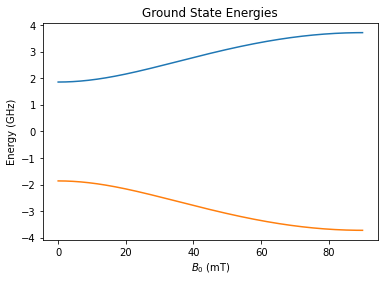

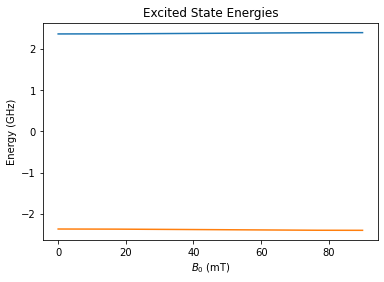

In [53]:

#Plot our energy levels
plt.plot(Bs*1E3,np.squeeze(np.real(FreqG[sqz])))
plt.title("Ground State Energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
plt.show()
plt.close()
plt.plot(Bs*1E3,np.squeeze(np.real(FreqE[sqz])))
plt.title("Excited State Energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
plt.show()
plt.close()

Determination of transition energies as the difference in energy level between each state and every other state.

Additionally repeats various vectors to make up larger vectors containing all optical and spin transitions.

In [54]:
#gets the transition values between each energy level
    #eachElemFunc calculates some function (default) subtraction between each of its two inputs
freq_def = np.real(spin.eachElemFunc(FreqE[sqz],FreqG[sqz],ax=1))
G_freq = np.real(spin.eachElemFunc(FreqG[sqz],FreqG[sqz],ax=1))
E_freq = np.real(spin.eachElemFunc(FreqE[sqz],FreqE[sqz],ax=1))


#Sorts our oscillator strengths to remove redundant axis
OS_s = np.real(np.squeeze(OS[sqz]))
OS_s_SG = np.squeeze(OS_SG[sqz])
OS_s_SE = np.squeeze(OS_SE[sqz])

#repeats Bstack to ensure correct dimensions for both optical and full transition plots
Bstack = np.tile(Bs,(ground.dim**2*1,1)).T
BBstack = np.tile(Bs,(ground.dim**2*3,1)).T

#stack all transitions and frequencies allowing them to be plotted together.
freq = np.hstack([freq_def,G_freq,E_freq])
OS_stack= np.real(np.hstack([OS_s,OS_s_SG,OS_s_SE]))



Nice plotting, generates a pixel value at each magnetic field and frequency coordinate based on a gaussian spread

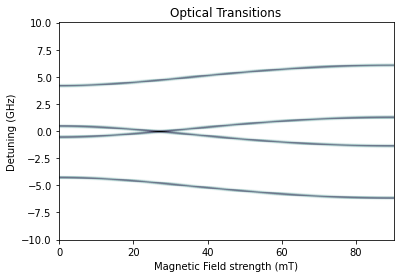

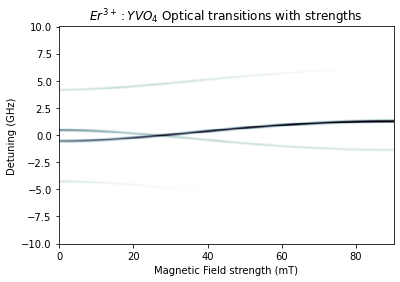

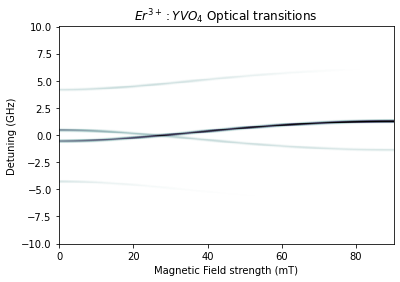

In [55]:
yi = np.linspace(-10,10,500)
cmapc = plt.cm.get_cmap('bone').copy()

tk = 0.08

spin.transitionPixelPlot(freq_def,Bs,frange=yi,width = tk,cmap=cmapc)
spin.transitionPixelPlot(freq_def,Bs,OS=OS_s,frange=yi,width = tk,cmap=cmapc,title="$Er^{3+}:YVO_{4}$ Optical transitions with strengths")
gx,gy,gz= spin.transitionPixelPlot(freq_def,Bs,frange=yi,OS=OS_s,width = tk,plot=False)
plt.pcolor(gx*1E3,gy,gz,shading='auto',cmap=cmapc,norm=clr.Normalize())
plt.xlabel('Magnetic Field strength (mT)')
plt.ylabel('Detuning (GHz)')
plt.title("$Er^{3+}:YVO_{4}$ Optical transitions")
plt.savefig("../Er_YVO_transitions.png")
plt.show()
plt.close()
